# KSSD TransU-Net 5-Fold CV (10 Epochs)

## 1. Setup

In [5]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import KFold
from PIL import Image
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
for gpu in tf.config.list_physical_devices("GPU"):
    print(" ", gpu)

TensorFlow: 2.20.0
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


## 2. GPU Configuration

In [7]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy(["/GPU:0", "/GPU:1"])
else:
    strategy = tf.distribute.get_strategy()

print("Replicas:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Replicas: 2


## 3. Hyperparameters

In [8]:
EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
N_FOLDS = 5
SEED = 42
FILTERS = [16, 32, 64, 128, 256]

## 4. Load Dataset

In [10]:
DATA_DIR = "/kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/data"
IMG_DIR = os.path.join(DATA_DIR, "image")
LABEL_DIR = os.path.join(DATA_DIR, "label")

common = sorted(set(os.listdir(IMG_DIR)) & set(os.listdir(LABEL_DIR)))
print(f"Matched pairs: {len(common)}")

X_list, Y_list = [], []
for fname in common:
    img = np.asarray(Image.open(os.path.join(IMG_DIR, fname)).convert("L"), dtype=np.float32) / 255.0
    msk = (np.asarray(Image.open(os.path.join(LABEL_DIR, fname)).convert("L"), dtype=np.float32) > 0).astype(np.float32)
    X_list.append(img[..., np.newaxis])
    Y_list.append(msk[..., np.newaxis])

X = np.array(X_list, dtype=np.float32)
Y = np.array(Y_list, dtype=np.float32)
del X_list, Y_list
gc.collect()

print(f"X: {X.shape}, Y: {Y.shape}")

Matched pairs: 838
X: (838, 512, 512, 1), Y: (838, 512, 512, 1)


## 5. Dice Loss & Metrics

In [11]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return 1.0 - (2.0 * intersection + smooth) / (denom + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))

def precision_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    pp = tf.reduce_sum(y_pred_bin, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (pp + smooth))

def recall_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    ap = tf.reduce_sum(y_true, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (ap + smooth))

## 6. Install keras-unet-collection & Patch for Keras 3

The library uses `tf.reshape` which is incompatible with Keras 3 KerasTensors.
We monkey-patch the source to use `keras.ops.reshape` instead.

In [12]:
!pip install -q keras-unet-collection

import keras_unet_collection._model_transunet_2d as _transunet_src
import inspect, textwrap, keras

original_source = inspect.getsource(_transunet_src.transunet_2d_base)

patched_source = original_source.replace(
    "tf.reshape(X, (-1, encode_size, encode_size, embed_dim))",
    "keras.ops.reshape(X, (-1, encode_size, encode_size, embed_dim))"
)

patched_source = textwrap.dedent(patched_source)
exec_namespace = {**vars(_transunet_src), "keras": keras, "tf": tf}
exec(compile(patched_source, "<patched>", "exec"), exec_namespace)

_transunet_src.transunet_2d_base = exec_namespace["transunet_2d_base"]

print("TransU-Net patched for Keras 3")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.4 MB/s eta 0:00:00
TransU-Net patched for Keras 3


## 7. Build TransU-Net

In [13]:
from keras_unet_collection import models as kuc

def build_transunet(input_shape=(512, 512, 1)):
    return kuc.transunet_2d(
        input_size=input_shape, filter_num=FILTERS, n_labels=1,
        stack_num_down=2, stack_num_up=2,
        embed_dim=192, num_mlp=384, num_heads=4, num_transformer=3,
        activation="ReLU", mlp_activation="GELU", output_activation="Sigmoid",
        batch_norm=True, pool=True, unpool=True,
        backbone=None, name="TransUNet",
    )

with strategy.scope():
    test_model = build_transunet()
print(f"TransU-Net: {test_model.count_params():,} params")
print(f"Input: {test_model.input_shape}, Output: {test_model.output_shape}")
del test_model
tf.keras.backend.clear_session()

TransU-Net: 4,747,553 params
Input: (None, 512, 512, 1), Output: (None, 512, 512, 1)


## 8. Create Folds

In [14]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(kf.split(X))
for i, (tr, va) in enumerate(folds, 1):
    print(f"Fold {i}: train={len(tr)}, val={len(va)}")

Fold 1: train=670, val=168
Fold 2: train=670, val=168
Fold 3: train=670, val=168
Fold 4: train=671, val=167
Fold 5: train=671, val=167


## 9. Train TransU-Net 5-Fold CV

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
all_histories = {}

for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
    print(f"FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*60}")

    train_ds = tf.data.Dataset.from_tensor_slices((X[train_idx], Y[train_idx]))
    train_ds = train_ds.shuffle(len(train_idx), reshuffle_each_iteration=True)
    train_ds = train_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X[val_idx], Y[val_idx]))
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    with strategy.scope():
        model = build_transunet()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss=dice_loss,
            metrics=[dice_coef, iou_metric, precision_metric, recall_metric],
        )

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    all_histories[fold_idx] = history.history

    model.save(f"/kaggle/working/TransUNet_fold{fold_idx}.keras")
    print(f"Fold {fold_idx} saved.")

    del model, train_ds, val_ds
    tf.keras.backend.clear_session()
    gc.collect()

FOLD 1/5
Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 120 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce IndexedSlices: 1 all_reduces, num_devices =2, group_size = 2, implementation = CommunicationImplementation.NCCL
83/83 ━━━━━━━━━━━━━━━━━━━━ 67s 488ms/step - dice_coef: 0.0078 - iou_metric: 0.0039 - loss: 0.9922 - precision_metric: 0.0240 - recall_metric: 0.9158 - val_dice_coef: 0.0029 - val_iou_metric: 0.0015 - val_loss: 0.9971 - val_precision_metric: 0.0015 - val_recall_metric: 0.9850
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 452ms/step - dice_coef: 0.0161 - iou_metric: 0.0083 - loss: 0.9839 - precision_metric: 0.0396 - recall_metric: 0.8073 - val_dice_coef: 0.0014 - val_iou_metric: 7.2057e-04 - val_loss: 0.9986 - val_precision_metric: 0.7031 - val_recall_metric: 0.2590
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 451ms/step - dice_coef: 0.0485 - iou_metric: 0.0284 - loss:

## 10. Results Summary

In [17]:
print(f"\n{'='*60}")
print("5-FOLD CV RESULTS TransU-Net (10 Epochs)")
print(f"{'='*60}\n")

fold_dice, fold_iou, fold_prec, fold_rec = [], [], [], []

for fold_idx in range(1, N_FOLDS + 1):
    h = all_histories[fold_idx]
    bd = max(h["val_dice_coef"])
    bi = max(h["val_iou_metric"])
    bp = max(h["val_precision_metric"])
    br = max(h["val_recall_metric"])
    fold_dice.append(bd); fold_iou.append(bi); fold_prec.append(bp); fold_rec.append(br)
    print(f"Fold {fold_idx}: Dice={bd:.4f}  IoU={bi:.4f}  Prec={bp:.4f}  Recall={br:.4f}")

print(f"\nMeanÂ±Std:")
print(f"  Dice:      {np.mean(fold_dice):.4f} Â± {np.std(fold_dice):.4f}")
print(f"  IoU:       {np.mean(fold_iou):.4f} Â± {np.std(fold_iou):.4f}")
print(f"  Precision: {np.mean(fold_prec):.4f} Â± {np.std(fold_prec):.4f}")
print(f"  Recall:    {np.mean(fold_rec):.4f} Â± {np.std(fold_rec):.4f}")


5-FOLD CV RESULTS TransU-Net (10 Epochs)

Fold 1: Dice=0.1138  IoU=0.0668  Prec=1.0000  Recall=0.9850
Fold 2: Dice=0.2962  IoU=0.1947  Prec=1.0000  Recall=0.3875
Fold 3: Dice=0.1319  IoU=0.0781  Prec=1.0000  Recall=0.9999
Fold 4: Dice=0.3457  IoU=0.2350  Prec=1.0000  Recall=1.0000
Fold 5: Dice=0.5374  IoU=0.3825  Prec=0.9578  Recall=0.9993

MeanÂ±Std:
  Dice:      0.2850 Â± 0.1551
  IoU:       0.1914 Â± 0.1156
  Precision: 0.9916 Â± 0.0169
  Recall:    0.8743 Â± 0.2435


## 11. Training Curves

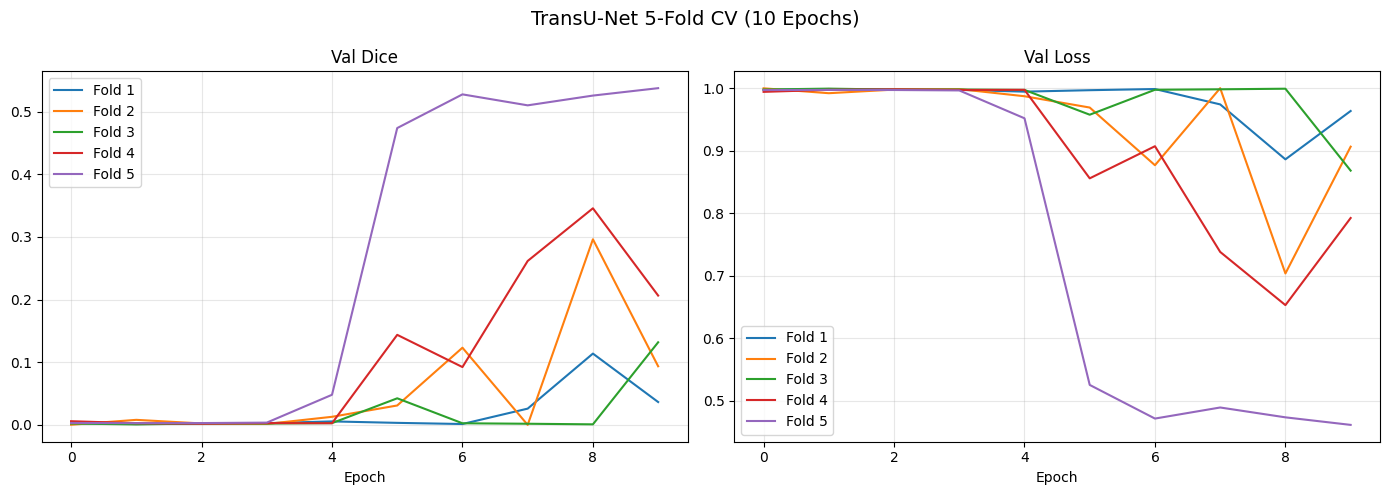

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold_idx in range(1, N_FOLDS + 1):
    h = all_histories[fold_idx]
    axes[0].plot(h["val_dice_coef"], label=f"Fold {fold_idx}")
    axes[1].plot(h["val_loss"], label=f"Fold {fold_idx}")

axes[0].set_title("Val Dice"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Val Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("TransU-Net 5-Fold CV (10 Epochs)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/transunet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Sample Predictions

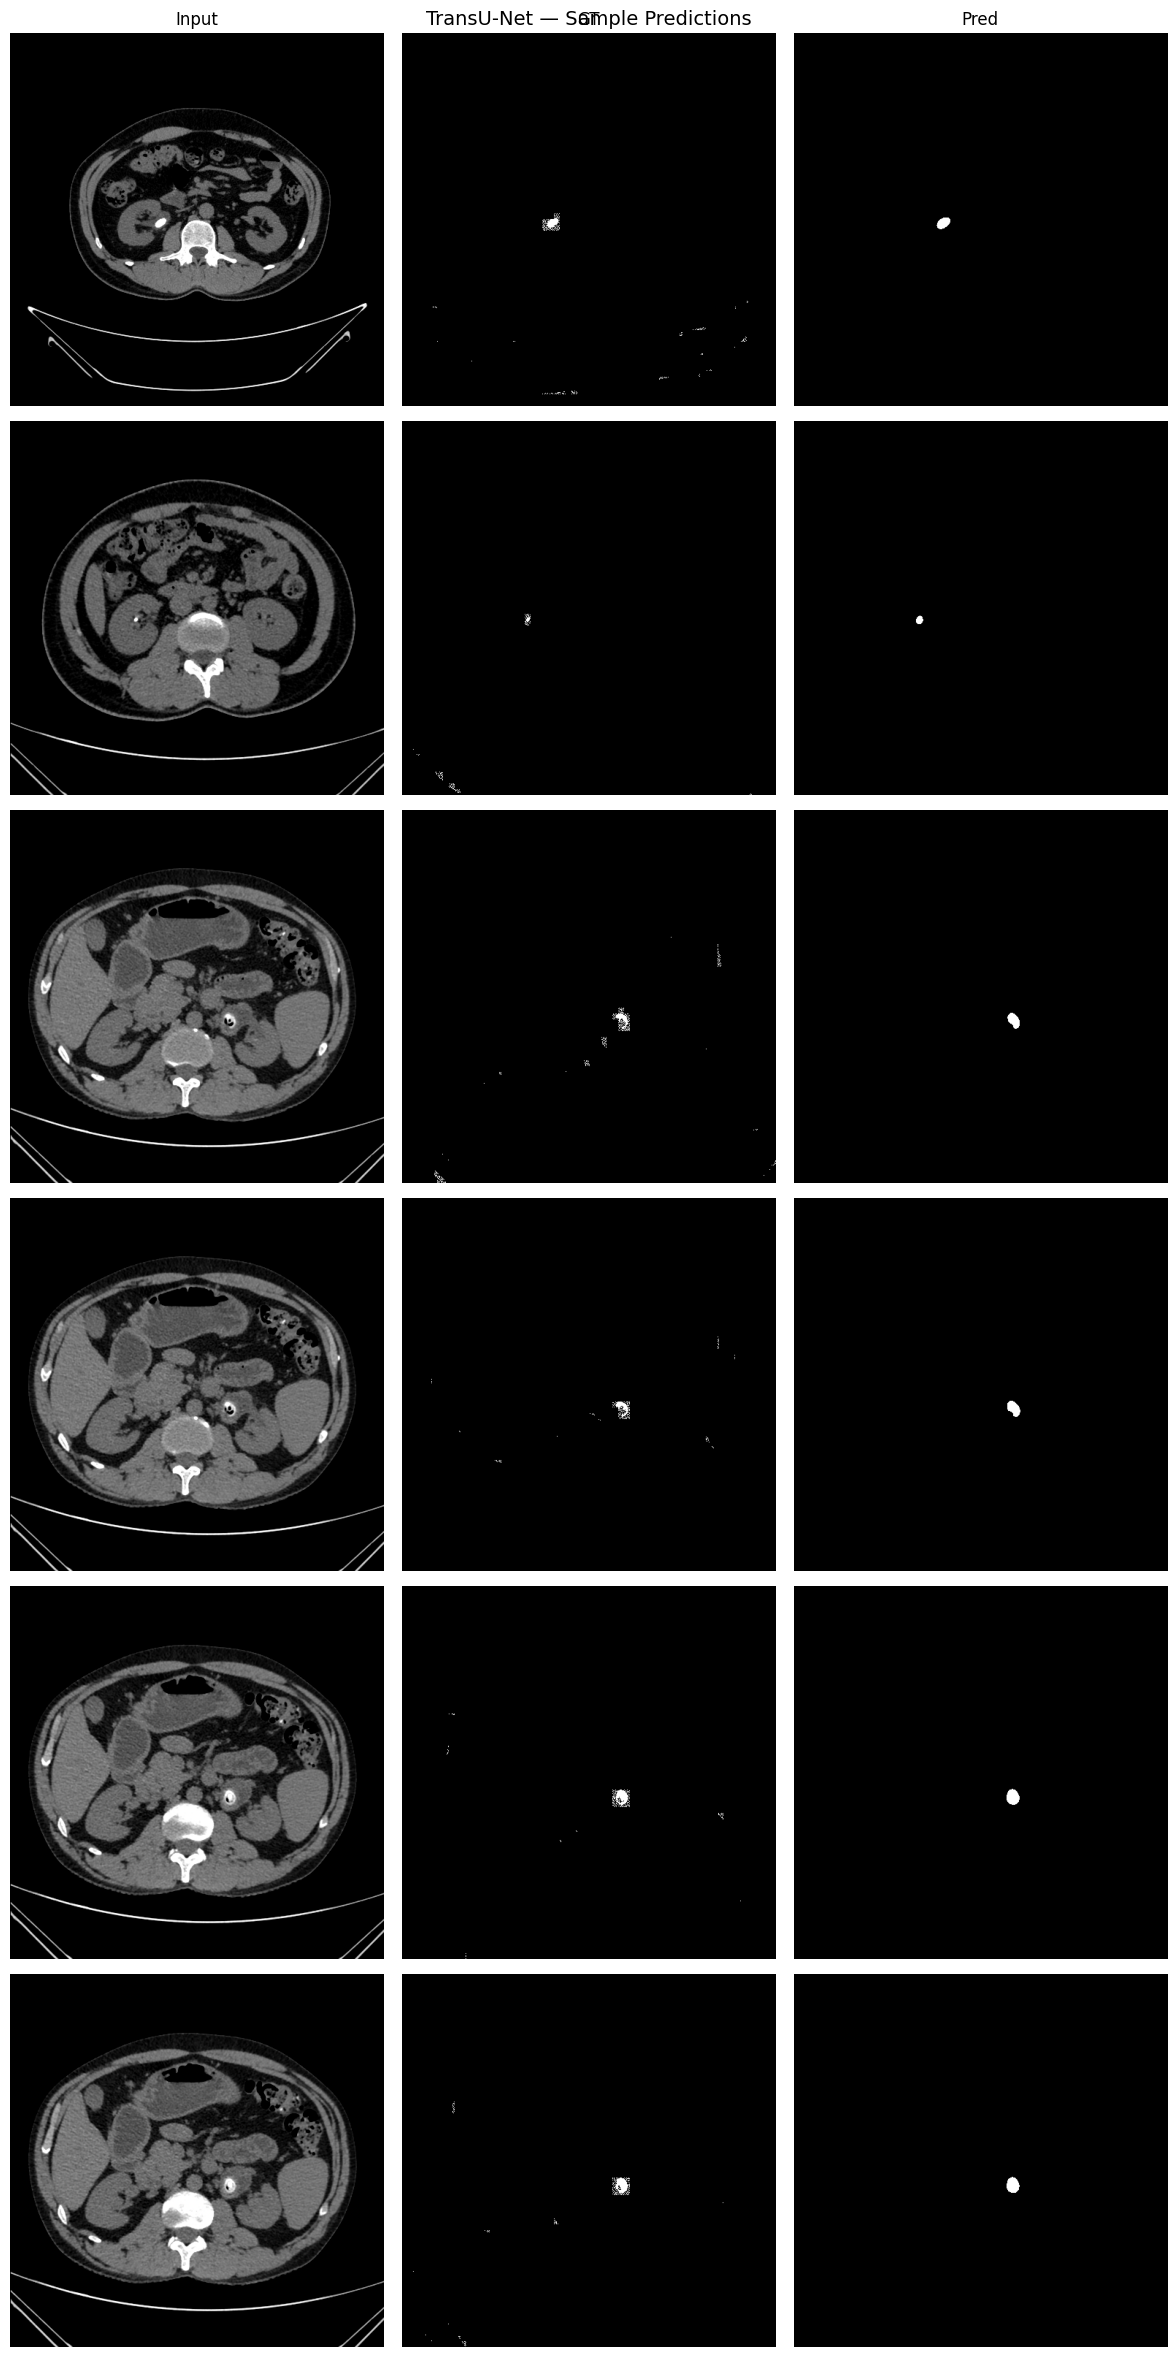

51310

In [24]:
import zipfile

keras_path = f"/kaggle/working/TransUNet_fold{N_FOLDS}.keras"
with zipfile.ZipFile(keras_path, 'r') as z:
    z.extract('model.weights.h5', '/tmp/transunet_tmp')

last_model = build_transunet()
last_model.load_weights('/tmp/transunet_tmp/model.weights.h5')

_, last_val_idx = folds[N_FOLDS - 1]
sample_indices = last_val_idx[:6]

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
for i, idx in enumerate(sample_indices):
    pred = last_model.predict(X[idx:idx+1], verbose=0)[0, ..., 0]
    axes[i, 0].imshow(X[idx, ..., 0], cmap="gray"); axes[i, 0].set_title("Input" if i==0 else "")
    axes[i, 1].imshow(Y[idx, ..., 0], cmap="gray"); axes[i, 1].set_title("GT" if i==0 else "")
    axes[i, 2].imshow(pred > 0.5, cmap="gray"); axes[i, 2].set_title("Pred" if i==0 else "")
for ax in axes.flat: ax.axis("off")

plt.suptitle("TransU-Net — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/transunet_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
del last_model; gc.collect()


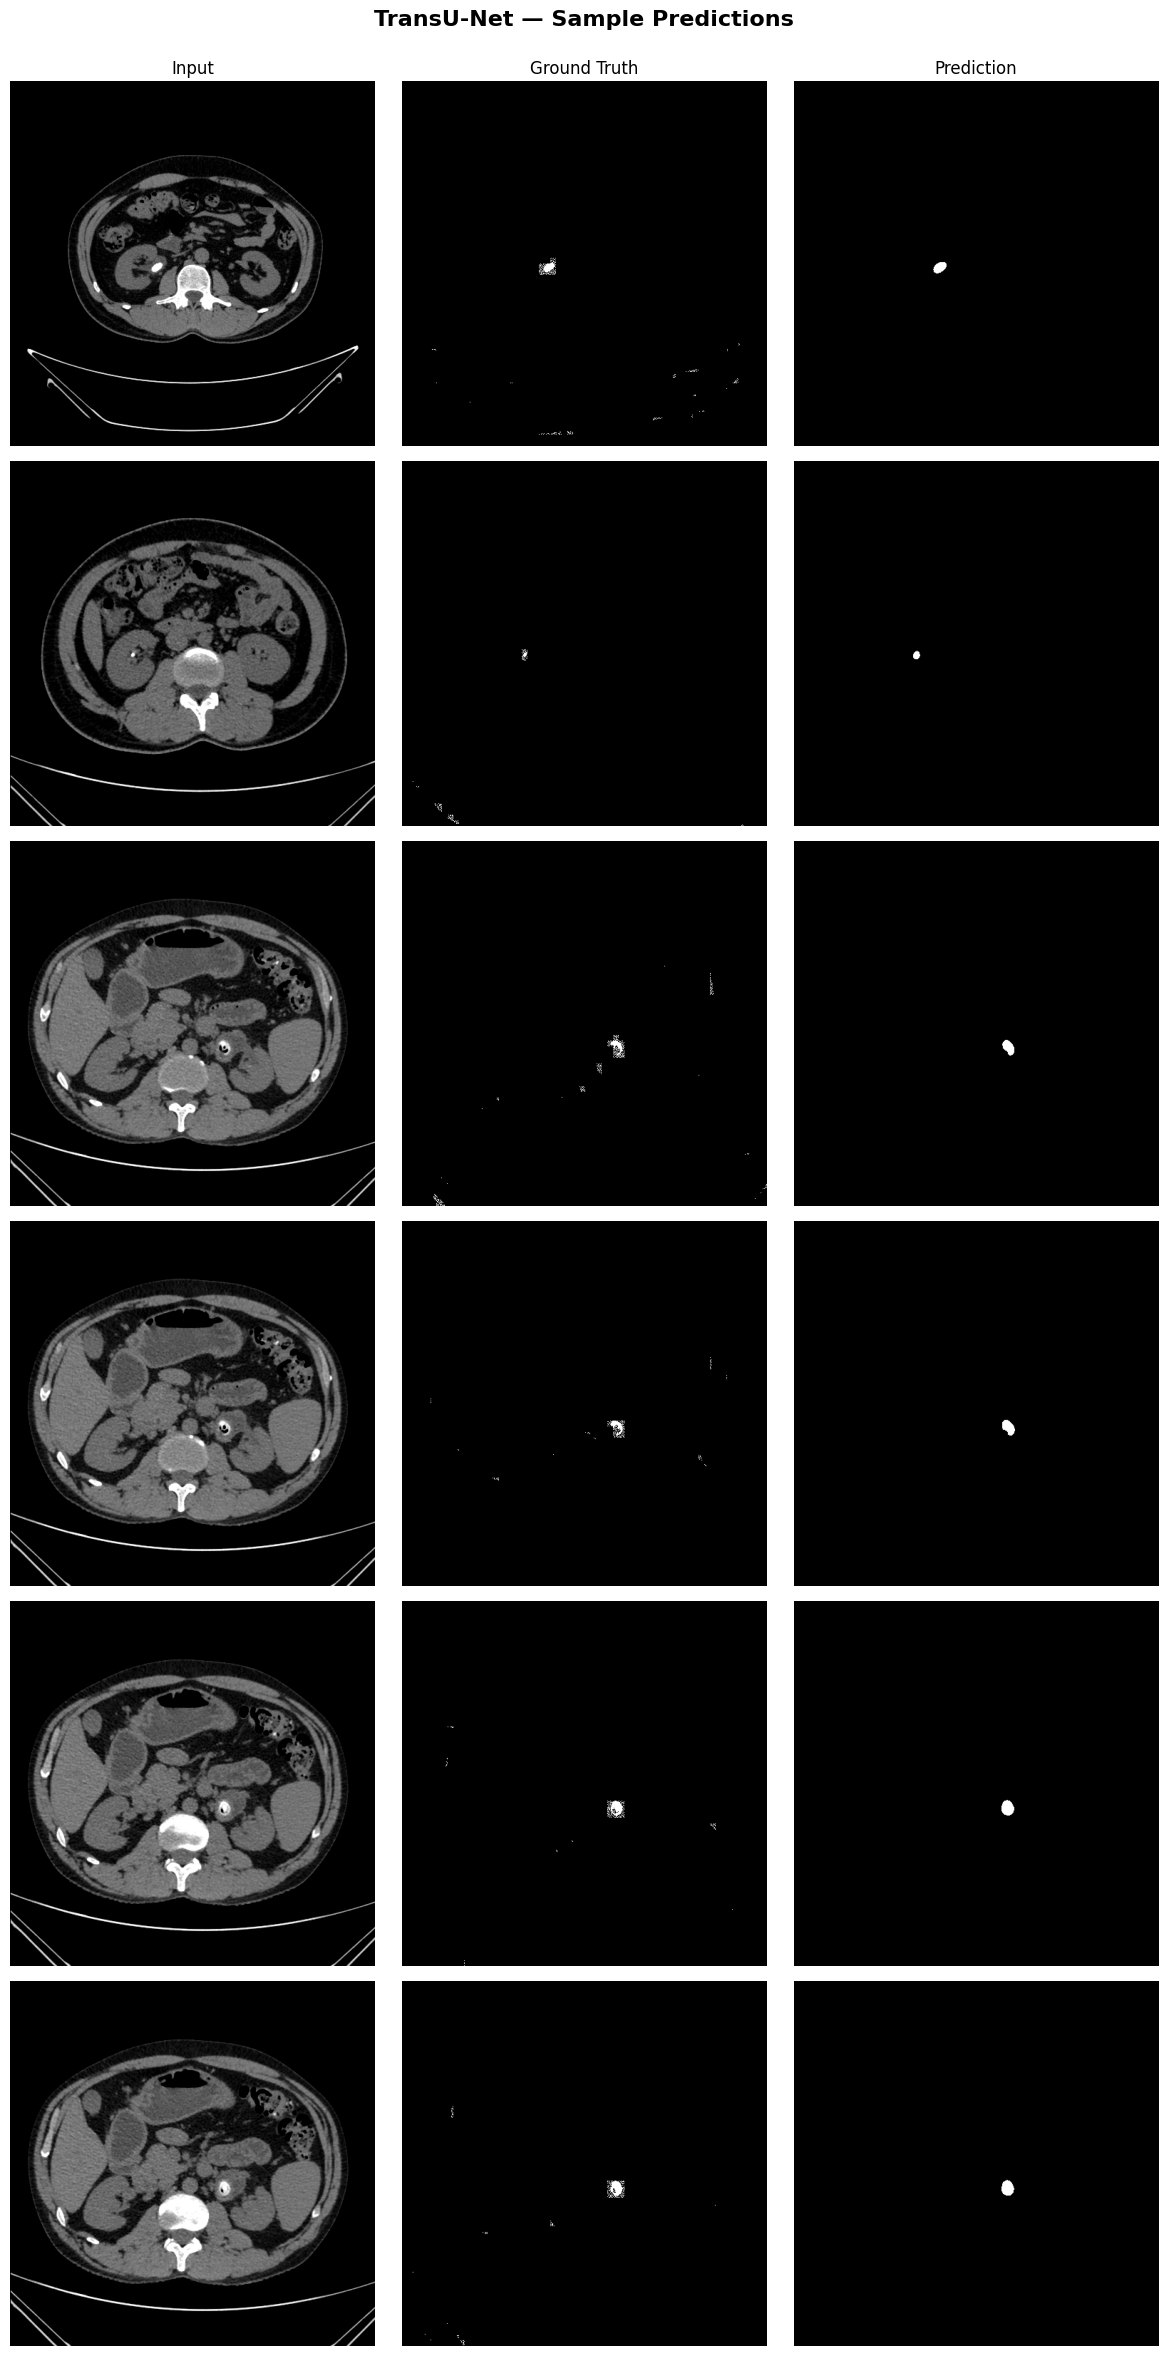

51310

In [25]:
import zipfile
import gc
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────
# Load the trained TransU-Net model
# ─────────────────────────────────────────────────────────────

keras_path = f"/kaggle/working/TransUNet_fold{N_FOLDS}.keras"

with zipfile.ZipFile(keras_path, "r") as z:
    z.extract("model.weights.h5", "/tmp/transunet_tmp")

last_model = build_transunet()
last_model.load_weights("/tmp/transunet_tmp/model.weights.h5")


# ─────────────────────────────────────────────────────────────
# Select validation samples
# ─────────────────────────────────────────────────────────────

_, last_val_idx = folds[N_FOLDS - 1]
sample_indices = last_val_idx[:6]


# ─────────────────────────────────────────────────────────────
# Generate predictions and visualize results
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    nrows=6,
    ncols=3,
    figsize=(12, 24)
)

for i, idx in enumerate(sample_indices):

    # Generate prediction
    pred = last_model.predict(
        X[idx:idx + 1],
        verbose=0
    )[0, ..., 0]

    # Input image
    axes[i, 0].imshow(
        X[idx, ..., 0],
        cmap="gray"
    )
    axes[i, 0].set_title(
        "Input" if i == 0 else "",
        fontsize=12
    )

    # Ground truth mask
    axes[i, 1].imshow(
        Y[idx, ..., 0],
        cmap="gray"
    )
    axes[i, 1].set_title(
        "Ground Truth" if i == 0 else "",
        fontsize=12
    )

    # Predicted mask
    axes[i, 2].imshow(
        pred > 0.5,
        cmap="gray"
    )
    axes[i, 2].set_title(
        "Prediction" if i == 0 else "",
        fontsize=12
    )


# Remove axis markings
for ax in axes.flat:
    ax.axis("off")


# ─────────────────────────────────────────────────────────────
# Finalize and save figure
# ─────────────────────────────────────────────────────────────

plt.suptitle(
    "TransU-Net — Sample Predictions",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(
    "/kaggle/working/transunet_predictions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Free memory
del last_model
gc.collect()